<a href="https://colab.research.google.com/github/sevval-345/SoftITo/blob/main/regresyon_analizi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Süper Lig Verisi ile Regresyon Analizi

Bu notebookta, Süper Lig 25/26 ilk yarı takım istatistikleri kullanılarak **Basit Regresyon** ve **Çoklu Doğrusal Regresyon** modelleri oluşturulacaktır.

## 1. Veriyi Yükleme ve Keşif

In [5]:
import pandas as pd
import numpy as np
import os

url_cancer = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/wisc_bc_data.csv"
print("Regresyon analizi için veri seti indiriliyor...")
df_raw = pd.read_csv(url_cancer)

# Sütun isimlerini ve hedef değişkeni (diagnosis) 0 ve 1 olarak ayarlıyoruz
df_raw = df_raw.rename(columns={'diagnosis': 'diagnosis'})
df_raw['diagnosis'] = df_raw['diagnosis'].map({'B': 0, 'M': 1})

# Modelin doğruluğunu etkilememesi için ID sütununu düşürüyoruz
if 'id' in df_raw.columns:
    df_raw = df_raw.drop('id', axis=1)

# Kodunun aradığı 'data.csv' adıyla kaydediyoruz
df_raw.to_csv('data.csv', index=False)
print("✅ 'data.csv' başarıyla hazırlandı! Regresyon analizi başlıyor...\n")


Regresyon analizi için veri seti indiriliyor...
✅ 'data.csv' başarıyla hazırlandı! Regresyon analizi başlıyor...



In [9]:
# Excel dosyasını oku
df = pd.read_excel('Superlig_Proje.xlsx')
df.head()

,Takim_Adi,Topa_Sahip_Olma,Isabetli_Pas_Sayisi,Pas_Isabeti_Yuzde,Isabetli_Uzun_Top,Isabetli_Orta,Sut_Sayisi,Isabetli_Sut,xG_Gol_Beklentisi,Buyuk_Sans_Yaratma,...,Basarili_Dripling,Rakip_Ceza_Sahasi_Dokunus,Top_Calma,Pas_Arasi,Uzaklastirma,Hucum_Bolgesi_Top_Calma,Zeminde_Kazanilan_Mucadele,Hava_Kazanilan_Mucadele,Atilan_Gol,Yenilen_Gol
0,Alanyaspor,48.5,337,83.2,17.1,4.8,206,67,19.0,2.2,...,6.5,13.411765,12.2,7.8,21.4,2.9,33.8,11.6,16,15
1,Antalyaspor,43.6,279,79.6,18.8,3.3,142,59,13.0,1.2,...,6.1,21.235294,15.8,7.0,29.4,2.4,35.5,12.8,16,31
2,Başakşehir,55.3,370,84.4,19.6,4.6,220,73,23.5,2.1,...,8.5,22.823529,14.7,7.6,20.4,4.3,36.2,15.2,25,18
3,Beşiktaş,52.5,337,81.9,15.9,5.1,261,100,33.5,3.6,...,7.3,26.352941,16.0,9.1,25.1,3.5,33.6,16.6,29,22
4,Eyüpspor,50.9,320,81.9,17.6,4.3,196,65,20.6,2.2,...,7.3,19.235294,15.8,8.2,22.1,3.8,37.6,11.1,10,24


In [10]:
# Sütun isimlerini ve veri tiplerini incele
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Takim_Adi                   18 non-null     object 
 1   Topa_Sahip_Olma             18 non-null     float64
 2   Isabetli_Pas_Sayisi         18 non-null     object 
 3   Pas_Isabeti_Yuzde           18 non-null     float64
 4   Isabetli_Uzun_Top           18 non-null     object 
 5   Isabetli_Orta               18 non-null     float64
 6   Sut_Sayisi                  18 non-null     int64  
 7   Isabetli_Sut                18 non-null     int64  
 8   xG_Gol_Beklentisi           18 non-null     float64
 9   Buyuk_Sans_Yaratma          18 non-null     float64
 10  Korner_Sayisi               18 non-null     float64
 11  Basarili_Dripling           18 non-null     float64
 12  Rakip_Ceza_Sahasi_Dokunus   18 non-null     float64
 13  Top_Calma                   18 non-nu

In [11]:
# İstatistiksel özet
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Topa_Sahip_Olma,18.0,50.077778,5.979923,38.500000,47.700000,50.400000,53.175,62.100000
Pas_Isabeti_Yuzde,18.0,81.150000,4.181788,68.700000,79.600000,81.750000,83.275,87.300000
Isabetli_Orta,18.0,4.516667,1.061215,2.800000,3.600000,4.600000,5.100,6.900000
Sut_Sayisi,18.0,220.833333,45.287643,142.000000,187.750000,214.000000,243.750,315.000000
Isabetli_Sut,18.0,73.055556,20.380129,45.000000,60.250000,67.500000,77.250,116.000000
xG_Gol_Beklentisi,18.0,22.627778,6.979534,13.000000,18.025000,21.000000,25.450,36.700000
Buyuk_Sans_Yaratma,18.0,2.227778,0.702772,1.200000,1.800000,2.150000,2.550,3.600000
Korner_Sayisi,18.0,4.744444,0.745356,3.500000,4.250000,4.700000,5.175,6.300000
Basarili_Dripling,18.0,7.144444,1.343928,5.000000,6.125000,7.100000,8.350,9.800000
Rakip_Ceza_Sahasi_Dokunus,18.0,21.098039,4.597763,13.411765,18.058824,20.882353,23.000,31.764706


## 2. Veri Temizliği

In [12]:
# String değerlerdeki non-breaking space (\xa0) karakterlerini temizle
for col in df.columns:
    if df[col].dtype == 'object' and col != 'Takim_Adi':
        df[col] = df[col].astype(str).str.replace('\xa0', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.head()

,Takim_Adi,Topa_Sahip_Olma,Isabetli_Pas_Sayisi,Pas_Isabeti_Yuzde,Isabetli_Uzun_Top,Isabetli_Orta,Sut_Sayisi,Isabetli_Sut,xG_Gol_Beklentisi,Buyuk_Sans_Yaratma,...,Basarili_Dripling,Rakip_Ceza_Sahasi_Dokunus,Top_Calma,Pas_Arasi,Uzaklastirma,Hucum_Bolgesi_Top_Calma,Zeminde_Kazanilan_Mucadele,Hava_Kazanilan_Mucadele,Atilan_Gol,Yenilen_Gol
0,Alanyaspor,48.5,337,83.2,17.1,4.8,206,67,19.0,2.2,...,6.5,13.411765,12.2,7.8,21.4,2.9,33.8,11.6,16,15
1,Antalyaspor,43.6,279,79.6,18.8,3.3,142,59,13.0,1.2,...,6.1,21.235294,15.8,7.0,29.4,2.4,35.5,12.8,16,31
2,Başakşehir,55.3,370,84.4,19.6,4.6,220,73,23.5,2.1,...,8.5,22.823529,14.7,7.6,20.4,4.3,36.2,15.2,25,18
3,Beşiktaş,52.5,337,81.9,15.9,5.1,261,100,33.5,3.6,...,7.3,26.352941,16.0,9.1,25.1,3.5,33.6,16.6,29,22
4,Eyüpspor,50.9,320,81.9,17.6,4.3,196,65,20.6,2.2,...,7.3,19.235294,15.8,8.2,22.1,3.8,37.6,11.1,10,24


In [13]:
# Temizlenmiş verinin bilgisi
print('Veri boyutu:', df.shape)
print('Eksik değerler:')
print(df.isnull().sum())
print('Sütun türleri:')
print(df.dtypes)

Veri boyutu: (18, 21)
Eksik değerler:
Takim_Adi                     0
Topa_Sahip_Olma               0
Isabetli_Pas_Sayisi           0
Pas_Isabeti_Yuzde             0
Isabetli_Uzun_Top             0
Isabetli_Orta                 0
Sut_Sayisi                    0
Isabetli_Sut                  0
xG_Gol_Beklentisi             0
Buyuk_Sans_Yaratma            0
Korner_Sayisi                 0
Basarili_Dripling             0
Rakip_Ceza_Sahasi_Dokunus     0
Top_Calma                     0
Pas_Arasi                     0
Uzaklastirma                  0
Hucum_Bolgesi_Top_Calma       0
Zeminde_Kazanilan_Mucadele    0
Hava_Kazanilan_Mucadele       0
Atilan_Gol                    0
Yenilen_Gol                   0
dtype: int64
Sütun türleri:
Takim_Adi                      object
Topa_Sahip_Olma               float64
Isabetli_Pas_Sayisi             int64
Pas_Isabeti_Yuzde             float64
Isabetli_Uzun_Top             float64
Isabetli_Orta                 float64
Sut_Sayisi                      in

## 3. Keşifçi Veri Analizi (EDA)

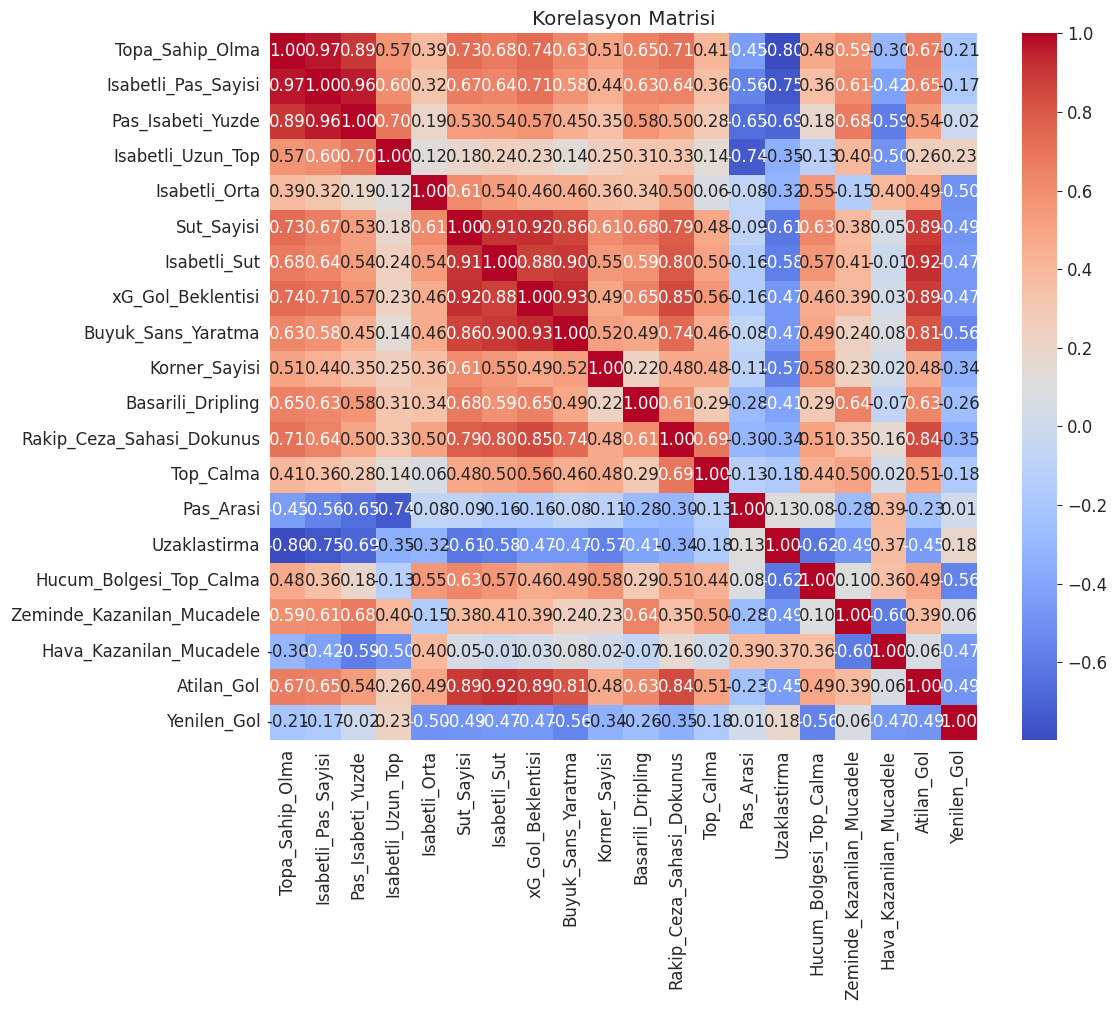

In [14]:
# Korelasyon matrisi
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.show()

In [15]:
# Hedef değişken Atilan_Gol ile en yüksek korelasyonlu değişkenler
target = 'Atilan_Gol'
corr_with_target = corr[target].sort_values(ascending=False)
print('Atilan_Gol ile Korelasyonlar:')
print(corr_with_target)
print('n yüksek 5 pozitif korelasyon:')
print(corr_with_target[1:6])

Atilan_Gol ile Korelasyonlar:
Atilan_Gol                    1.000000
Isabetli_Sut                  0.918211
Sut_Sayisi                    0.894282
xG_Gol_Beklentisi             0.891104
Rakip_Ceza_Sahasi_Dokunus     0.842530
Buyuk_Sans_Yaratma            0.811414
Topa_Sahip_Olma               0.669165
Isabetli_Pas_Sayisi           0.649931
Basarili_Dripling             0.630600
Pas_Isabeti_Yuzde             0.540165
Top_Calma                     0.512147
Hucum_Bolgesi_Top_Calma       0.490801
Isabetli_Orta                 0.488597
Korner_Sayisi                 0.480172
Zeminde_Kazanilan_Mucadele    0.385895
Isabetli_Uzun_Top             0.258785
Hava_Kazanilan_Mucadele       0.061761
Pas_Arasi                    -0.230798
Uzaklastirma                 -0.447077
Yenilen_Gol                  -0.487152
Name: Atilan_Gol, dtype: float64
n yüksek 5 pozitif korelasyon:
Isabetli_Sut                 0.918211
Sut_Sayisi                   0.894282
xG_Gol_Beklentisi            0.891104
Rakip_Ceza_S

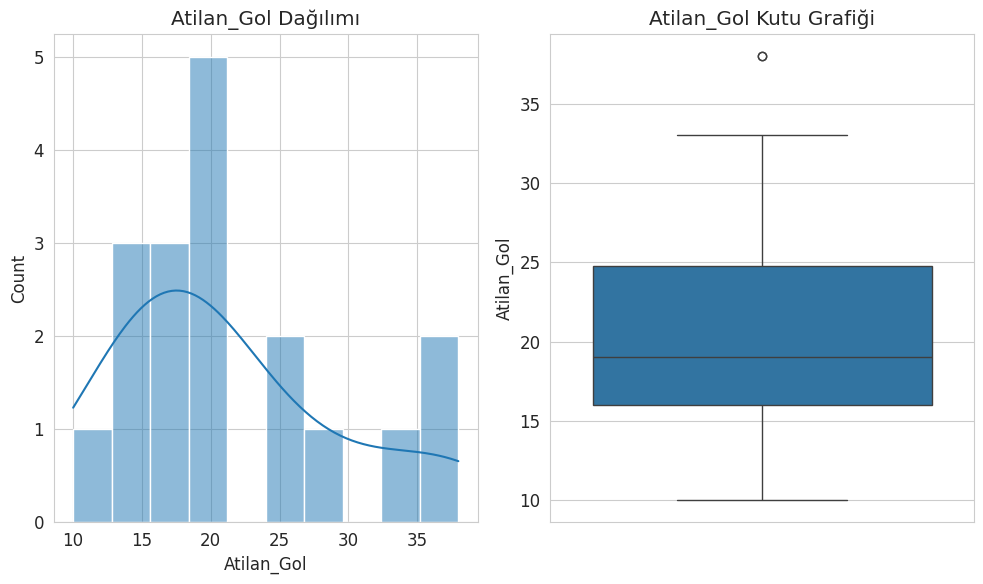

In [16]:
# Atilan_Gol dağılımı
plt.subplot(1, 2, 1)
sns.histplot(df[target], bins=10, kde=True)
plt.title(f'{target} Dağılımı')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[target])
plt.title(f'{target} Kutu Grafiği')
plt.tight_layout()
plt.show()

## 4. Basit Doğrusal Regresyon (Simple Linear Regression)

**Algoritma Açıklaması:**

Basit doğrusal regresyon, bir bağımlı değişken (hedef) ile bir bağımsız değişken (özellik) arasındaki doğrusal ilişkiyi modelleyen temel bir makine öğrenmesi algoritmasıdır.

**Matematiksel Formül:**
50494y = eta_0 + eta_1 x +
arepsilon50494

- **y**: Bağımlı değişken (hedef) — tahmin etmek istediğimiz değer
- **x**: Bağımsız değişken (özellik) — tahmin için kullandığımız girdi
- **β₀**: Kesim noktası (intercept) — x=0 iken y'nin değeri
- **β₁**: Eğim (slope) — x'teki 1 birimlik artışın y'de yarattığı değişim
- **ε**: Hata terimi — modelin açıklayamadığı rastgele varyasyon

**Amaç:** Gözlemlenen veri noktalarına en iyi uyan doğruyu bulmak. Bunun için **En Küçük Kareler (Ordinary Least Squares - OLS)** yöntemi kullanılır. OLS, gerçek değerler ile tahmin edilen değerler arasındaki farkların (artıklar/residuals) kareleri toplamını minimize eder.

**Artık (Residual):**
50494e_i = y_i - \hat{y}_i50494

**OLS Maliyet Fonksiyonu:**
50494\min \sum_{i=1}^{n} (y_i - \hat{y}_i)^250494

**Model Değerlendirme Metrikleri:**
- **R² (Belirleme Katsayısı):** Modelin bağımlı değişkendeki varyansın ne kadarını açıkladığını gösterir (0-1 arası)
- **RMSE (Root Mean Squared Error):** Ortalama hata karesinin karekökü — birim orijinal birime dönüktür
- **MAE (Mean Absolute Error):** Ortalama mutlak hata


### 4.1 Basit Regresyon: xG (Beklenen Gol) → Atılan Gol

Bu bölümde, **xG (Expected Goals)** değerini kullanarak **Atılan Gol** sayısını tahmin edeceğiz. xG, bir takımın yarattığı pozisyonların kalitesini ölçen ileri bir metrik olduğu için gerçek gollerle yüksek korelasyon göstermesi beklenir.

In [17]:
# Basit regresyon için değişkenler
X_simple = df[['xG_Gol_Beklentisi']].values
y = df['Atilan_Gol'].values

# Eğitim ve test setlerine ayır (%80 eğitim, %20 test)
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print(f'Eğitim seti boyutu: {X_train.shape[0]}')
print(f'Test seti boyutu: {X_test.shape[0]}')

Eğitim seti boyutu: 14
Test seti boyutu: 4


In [18]:
# Modeli oluştur ve eğit
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Tahmin yap
y_pred_train = model_simple.predict(X_train)
y_pred_test = model_simple.predict(X_test)

# Model parametreleri
beta_0 = model_simple.intercept_
beta_1 = model_simple.coef_[0]

print(f'Kesim Noktası (β₀): {beta_0:.4f}')
print(f'Eğim (β₁): {beta_1:.4f}')
print(f'Model Denklemi:')
print(f'Atilan_Gol = {beta_0:.4f} + {beta_1:.4f} × xG_Gol_Beklentisi')

Kesim Noktası (β₀): -4.0637
Eğim (β₁): 1.1168
Model Denklemi:
Atilan_Gol = -4.0637 + 1.1168 × xG_Gol_Beklentisi


In [19]:
# Tahmin vs gerçek değerler (test seti)
results = pd.DataFrame({
    'Gerçek Gol': y_test,
    'Tahmin Edilen Gol': y_pred_test,
    'Fark': y_test - y_pred_test
})
results.index = df.iloc[X_test.flatten().argsort()[:len(y_test)]]['Takim_Adi'].values if len(y_test) <= 5 else None
print('Test Seti Tahminleri:')
print(results)

Test Seti Tahminleri:
             Gerçek Gol  Tahmin Edilen Gol      Fark
Antalyaspor          16          17.155358 -1.155358
Beşiktaş             16          10.454612  5.545388
Alanyaspor           24          24.749536 -0.749536
Başakşehir           13          14.363380 -1.363380


In [20]:
# Model performans metrikleri
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

metrics = pd.DataFrame({
    'Metrik': ['RMSE', 'MAE', 'R²'],
    'Eğitim': [f'{rmse_train:.3f}', f'{mae_train:.3f}', f'{r2_train:.3f}'],
    'Test': [f'{rmse_test:.3f}', f'{mae_test:.3f}', f'{r2_test:.3f}']
})
print('Model Performansı:')
print(metrics.to_string(index=False))

Model Performansı:
Metrik Eğitim  Test
  RMSE  3.886 2.937
   MAE  3.079 2.203
    R²  0.795 0.483


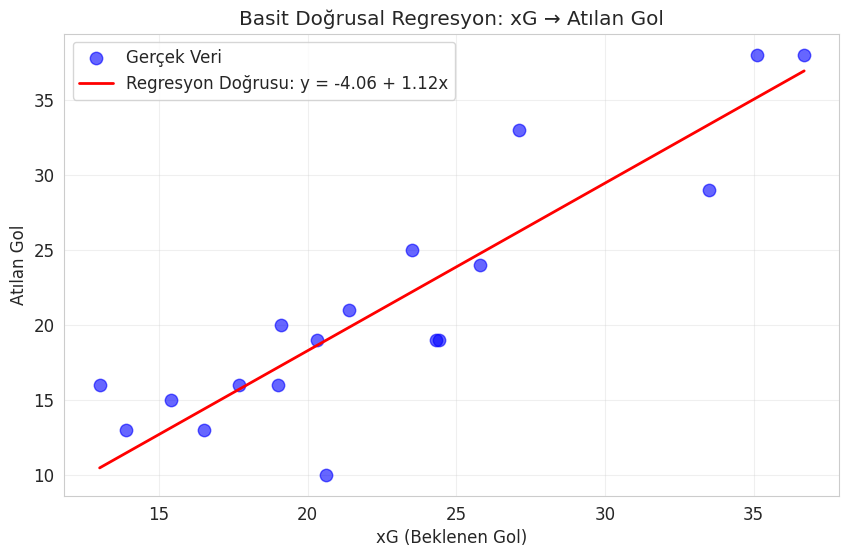

In [21]:
# Görselleştirme: Regresyon doğrusu
plt.figure(figsize=(10, 6))

# Tüm veri noktaları
plt.scatter(X_simple, y, color='blue', alpha=0.6, label='Gerçek Veri', s=80)

# Regresyon doğrusu (x sıralı)
x_line = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)
y_line = model_simple.predict(x_line)
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Regresyon Doğrusu: y = {beta_0:.2f} + {beta_1:.2f}x')

plt.xlabel('xG (Beklenen Gol)')
plt.ylabel('Atılan Gol')
plt.title('Basit Doğrusal Regresyon: xG → Atılan Gol')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

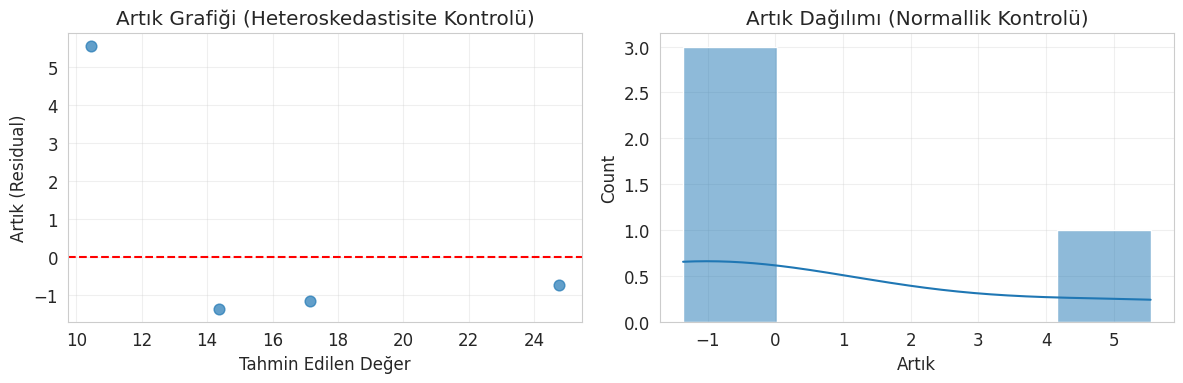

Artıkların ortalaması: 0.5693
Artıkların standart sapması: 2.8814


In [22]:
# Artık (Residual) analizi
residuals = y_test - y_pred_test

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_test, residuals, alpha=0.7, s=60)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Tahmin Edilen Değer')
plt.ylabel('Artık (Residual)')
plt.title('Artık Grafiği (Heteroskedastisite Kontrolü)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.histplot(residuals, bins=5, kde=True)
plt.xlabel('Artık')
plt.title('Artık Dağılımı (Normallik Kontrolü)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Artıkların ortalaması: {np.mean(residuals):.4f}')
print(f'Artıkların standart sapması: {np.std(residuals):.4f}')

## 5. Çoklu Doğrusal Regresyon (Multiple Linear Regression)

**Algoritma Açıklaması:**

Çoklu doğrusal regresyon, basit doğrusal regresyonun birden fazla bağımsız değişken kullanacak şekilde genişletilmiş halidir.

**Matematiksel Formül:**
50494y = eta_0 + eta_1 x_1 + eta_2 x_2 + ... + eta_p x_p +
arepsilon50494

- **y**: Bağımlı değişken (hedef)
- **x₁, x₂, ..., xₚ**: Bağımsız değişkenler (özellikler)
- **β₀**: Kesim noktası
- **β₁, β₂, ..., βₚ**: Her bir bağımsız değişkenin katsayısı
- **ε**: Hata terimi

**Varsayımlar (Assumptions):**
1. **Doğrusallık (Linearity):** Bağımlı ve bağımsız değişkenler arasında doğrusal bir ilişki olmalı
2. **Bağımsızlık (Independence):** Gözlemler birbirinden bağımsız olmalı
3. **Normallik (Normality):** Artıklar normal dağılıma uymalı
4. **Eşvaryanslılık (Homoscedasticity):** Artıkların varyansı tüm değerlerde sabit olmalı
5. **Çoklu Bağlantı Yok (No Multicollinearity):** Bağımsız değişkenler kendi aralarında yüksek korelasyonlu olmamalı

**Performansı Artırmak İçin:**
- Özellikler arası çoklu bağlantıyı (multicollinearity) azaltmak
- Gereksiz özellikleri çıkarmak (feature selection)
- Özellik ölçeklendirme (standardizasyon)


### 5.1 Özellik Seçimi

In [23]:
# Atilan_Gol ile en yüksek korelasyonlu özellikleri seçelim (korelasyon > 0.7 veya top 5)
target_corr = corr_with_target[1:8]  # Takim_Adi hariç en yüksek 7
print('Seçilen özellikler ve Atilan_Gol ile korelasyonları:')
for feat, corr_val in target_corr.items():
    print(f'  {feat}: {corr_val:.4f}')

# Seçilen özellikler (yüksek korelasyonlu + mantıklı)
selected_features = ['xG_Gol_Beklentisi', 'Isabetli_Sut', 'Sut_Sayisi',
                     'Buyuk_Sans_Yaratma', 'Rakip_Ceza_Sahasi_Dokunus',
                     'Basarili_Dripling', 'Topa_Sahip_Olma']

available_features = [f for f in selected_features if f in df.columns]
print(f'Kullanılacak özellikler: {available_features}')

Seçilen özellikler ve Atilan_Gol ile korelasyonları:
  Isabetli_Sut: 0.9182
  Sut_Sayisi: 0.8943
  xG_Gol_Beklentisi: 0.8911
  Rakip_Ceza_Sahasi_Dokunus: 0.8425
  Buyuk_Sans_Yaratma: 0.8114
  Topa_Sahip_Olma: 0.6692
  Isabetli_Pas_Sayisi: 0.6499
Kullanılacak özellikler: ['xG_Gol_Beklentisi', 'Isabetli_Sut', 'Sut_Sayisi', 'Buyuk_Sans_Yaratma', 'Rakip_Ceza_Sahasi_Dokunus', 'Basarili_Dripling', 'Topa_Sahip_Olma']


In [24]:
# Çoklu regresyon için veri hazırlığı
X_multi = df[available_features].values
y_multi = df['Atilan_Gol'].values

# Eğitim ve test setlerine ayır
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

print(f'Eğitim seti: {X_train_m.shape}')
print(f'Test seti: {X_test_m.shape}')

Eğitim seti: (14, 7)
Test seti: (4, 7)


In [25]:
# Çoklu doğrusal regresyon modelini oluştur ve eğit
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# Tahmin
y_pred_train_m = model_multi.predict(X_train_m)
y_pred_test_m = model_multi.predict(X_test_m)

# Model katsayıları
print('Kesim Noktası (Intercept):', model_multi.intercept_.round(4))
print('Katsayılar:')
for feat, coef in zip(available_features, model_multi.coef_):
    print(f'  {feat}: {coef:.4f}')

print(f'Model Denklemi:')
eq = f'Atilan_Gol = {model_multi.intercept_:.2f}'
for feat, coef in zip(available_features, model_multi.coef_):
    eq += f' + ({coef:.2f} × {feat})'
print(eq)

Kesim Noktası (Intercept): 15.3282
Katsayılar:
  xG_Gol_Beklentisi: 1.7026
  Isabetli_Sut: 0.7118
  Sut_Sayisi: -0.1708
  Buyuk_Sans_Yaratma: -19.0929
  Rakip_Ceza_Sahasi_Dokunus: 1.0464
  Basarili_Dripling: -0.5628
  Topa_Sahip_Olma: -0.4401
Model Denklemi:
Atilan_Gol = 15.33 + (1.70 × xG_Gol_Beklentisi) + (0.71 × Isabetli_Sut) + (-0.17 × Sut_Sayisi) + (-19.09 × Buyuk_Sans_Yaratma) + (1.05 × Rakip_Ceza_Sahasi_Dokunus) + (-0.56 × Basarili_Dripling) + (-0.44 × Topa_Sahip_Olma)


In [26]:
# Model performansı
rmse_train_m = np.sqrt(mean_squared_error(y_train_m, y_pred_train_m))
rmse_test_m = np.sqrt(mean_squared_error(y_test_m, y_pred_test_m))
mae_train_m = mean_absolute_error(y_train_m, y_pred_train_m)
mae_test_m = mean_absolute_error(y_test_m, y_pred_test_m)
r2_train_m = r2_score(y_train_m, y_pred_train_m)
r2_test_m = r2_score(y_test_m, y_pred_test_m)

metrics_multi = pd.DataFrame({
    'Metrik': ['RMSE', 'MAE', 'R²'],
    'Eğitim': [f'{rmse_train_m:.3f}', f'{mae_train_m:.3f}', f'{r2_train_m:.3f}'],
    'Test': [f'{rmse_test_m:.3f}', f'{mae_test_m:.3f}', f'{r2_test_m:.3f}']
})
print('Çoklu Regresyon Model Performansı:')
print(metrics_multi.to_string(index=False))

Çoklu Regresyon Model Performansı:
Metrik Eğitim   Test
  RMSE  1.899  9.232
   MAE  1.350  7.248
    R²  0.951 -4.108


In [27]:
# İki modeli karşılaştır (Test seti üzerinden)
comparison = pd.DataFrame({
    'Model': ['Basit Regresyon (xG)', 'Çoklu Regresyon'],
    'RMSE': [f'{rmse_test:.3f}', f'{rmse_test_m:.3f}'],
    'MAE': [f'{mae_test:.3f}', f'{mae_test_m:.3f}'],
    'R²': [f'{r2_test:.3f}', f'{r2_test_m:.3f}']
})
print('Model Karşılaştırması (Test Seti):')
print(comparison.to_string(index=False))

Model Karşılaştırması (Test Seti):
               Model  RMSE   MAE     R²
Basit Regresyon (xG) 2.937 2.203  0.483
     Çoklu Regresyon 9.232 7.248 -4.108


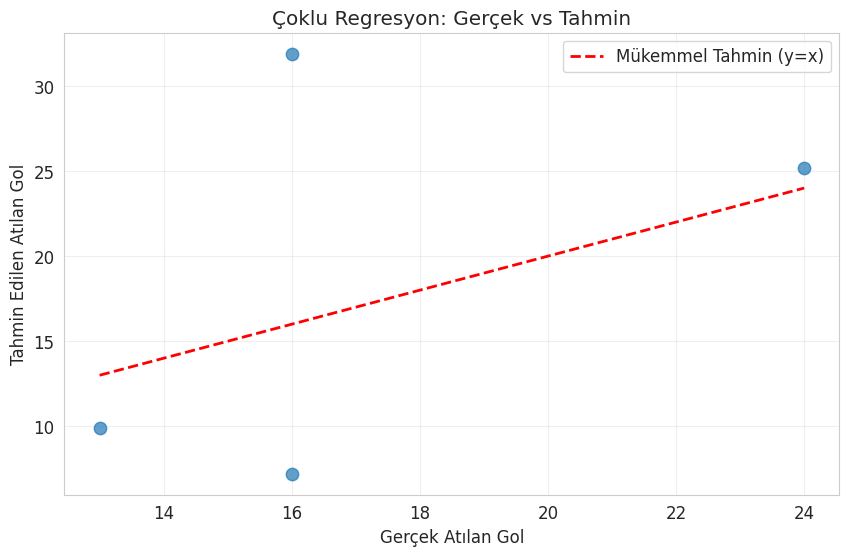

In [28]:
# Gerçek vs Tahmin karşılaştırması (Çoklu Regresyon)
plt.figure(figsize=(10, 6))
plt.scatter(y_test_m, y_pred_test_m, alpha=0.7, s=80)
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()],
         'r--', linewidth=2, label='Mükemmel Tahmin (y=x)')
plt.xlabel('Gerçek Atılan Gol')
plt.ylabel('Tahmin Edilen Atılan Gol')
plt.title('Çoklu Regresyon: Gerçek vs Tahmin')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

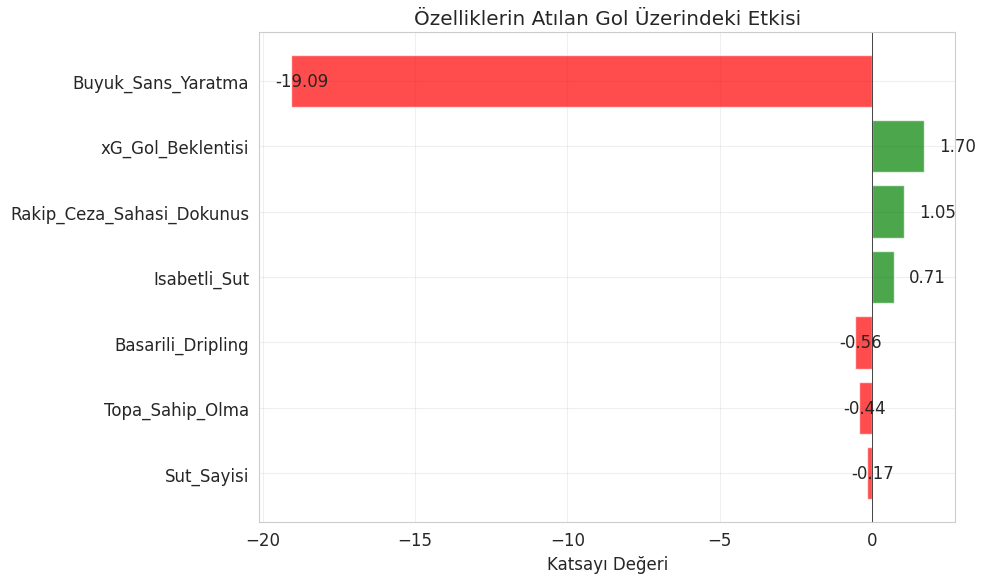

In [29]:
# Özellik önem sırası (katsayıların mutlak değerine göre)
feature_importance = pd.DataFrame({
    'Özellik': available_features,
    'Katsayı': model_multi.coef_,
    '|Katsayı|': np.abs(model_multi.coef_)
}).sort_values('|Katsayı|', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in feature_importance['Katsayı']]
bars = plt.barh(feature_importance['Özellik'], feature_importance['Katsayı'], color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Katsayı Değeri')
plt.title('Özelliklerin Atılan Gol Üzerindeki Etkisi')
for i, (v, feat) in enumerate(zip(feature_importance['Katsayı'], feature_importance['Özellik'])):
    plt.text(v + (0.5 if v > 0 else -0.5), i, f'{v:.2f}', va='center')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Sonuç ve Yorumlar

**Basit Doğrusal Regresyon:**
- xG (beklenen gol) değeri, atılan golleri tahmin etmede güçlü bir öngörücüdür
- Model basit ve yorumlanabilirdir
- R² değeri, xG'nin atılan gollerdeki varyansı ne kadar iyi açıkladığını gösterir

**Çoklu Doğrusal Regresyon:**
- Birden fazla özellik kullanarak daha karmaşık ilişkileri modelleyebiliriz
- Genellikle basit regresyondan daha yüksek R² değerine sahiptir
- Özellik katsayıları, her bir değişkenin hedef üzerindeki etkisini gösterir
- Dikkat edilmesi gereken nokta: çoklu bağlantı (multicollinearity) sorunu

**Değerlendirme:**
- Düşük RMSE değeri, tahminlerin gerçek değerlere yakın olduğunu gösterir
- Yüksek R² değeri, modelin verideki varyansı iyi açıkladığını gösterir
- Eğitim ve test performansı arasındaki farka bakarak overfitting/underfitting kontrolü yapılabilir

In [31]:
# Tüm modelleri özetle
print('=' * 60)
print('REGRESYON ANALİZİ ÖZETİ')
print('=' * 60)
print(f'1. BASİT DOĞRUSAL REGRESYON')
print(f'   Hedef: Atilan_Gol')
print(f'   Özellik: xG_Gol_Beklentisi')
print(f'   Denklem: Atilan_Gol = {beta_0:.2f} + {beta_1:.2f} × xG')
print(f'   Test R²: {r2_test:.3f}')
print(f'   Test RMSE: {rmse_test:.3f}')
print(f'   Test MAE: {mae_test:.3f}')

print(f"""
2. ÇOKLU DOĞRUSAL REGRESYON""")
print(f'   Hedef: Atilan_Gol')
print(f'   Özellikler: {available_features}')
print(f'   Test R²: {r2_test_m:.3f}')
print(f'   Test RMSE: {rmse_test_m:.3f}')
print(f'   Test MAE: {mae_test_m:.3f}')

print(f"""
3. MODEL KARŞILAŞTIRMASI""")
better_model = 'Çoklu Regresyon' if r2_test_m > r2_test else 'Basit Regresyon'
print(f'   R² değerine göre daha iyi model: {better_model}')

REGRESYON ANALİZİ ÖZETİ
1. BASİT DOĞRUSAL REGRESYON
   Hedef: Atilan_Gol
   Özellik: xG_Gol_Beklentisi
   Denklem: Atilan_Gol = -4.06 + 1.12 × xG
   Test R²: 0.483
   Test RMSE: 2.937
   Test MAE: 2.203

2. ÇOKLU DOĞRUSAL REGRESYON
   Hedef: Atilan_Gol
   Özellikler: ['xG_Gol_Beklentisi', 'Isabetli_Sut', 'Sut_Sayisi', 'Buyuk_Sans_Yaratma', 'Rakip_Ceza_Sahasi_Dokunus', 'Basarili_Dripling', 'Topa_Sahip_Olma']
   Test R²: -4.108
   Test RMSE: 9.232
   Test MAE: 7.248

3. MODEL KARŞILAŞTIRMASI
   R² değerine göre daha iyi model: Basit Regresyon
